# Compute STalign on point arrays

This notebook shows the lower-level `sq.experimental.tl.stalign_tools` workflow with explicit preprocessing, fitting, and point transformation.

The Squidpy MERFISH coordinates in this environment are normalized to `[0, 1]`, so the example rescales the crop before rasterization to make the solver inputs and plots easier to inspect.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not locate the repository root.")
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np

import squidpy as sq

/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  inner = partial(_inner_join_spatialelement_table)
/Users/selman/project

In [2]:
adata = sq.datasets.merfish()
points_xy = np.asarray(adata.obsm["spatial"], dtype=float)

xmin, xmax = np.quantile(points_xy[:, 0], [0.18, 0.36])
ymin, ymax = np.quantile(points_xy[:, 1], [0.22, 0.42])
mask = (points_xy[:, 0] >= xmin) & (points_xy[:, 0] <= xmax) & (points_xy[:, 1] >= ymin) & (points_xy[:, 1] <= ymax)

source_xy = points_xy[mask] * 1000.0
center = source_xy.mean(axis=0, keepdims=True)
angle = np.deg2rad(8.0)
rotation = np.array(
    [
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle), np.cos(angle)],
    ]
)
target_xy = (source_xy - center) @ rotation.T + center + np.array([120.0, -80.0])

landmark_idx = np.linspace(0, source_xy.shape[0] - 1, 8, dtype=int)
landmarks_source_xy = source_xy[landmark_idx]
landmarks_target_xy = target_xy[landmark_idx]

source_rc = source_xy[:, [1, 0]]
target_rc = target_xy[:, [1, 0]]
landmarks_source_rc = landmarks_source_xy[:, [1, 0]]
landmarks_target_rc = landmarks_target_xy[:, [1, 0]]

print(f"Source cells: {source_xy.shape[0]}")
print(f"Source range: {np.ptp(source_xy, axis=0)}")

INFO     Downloading merfish.h5ad from https://exampledata.scverse.org/squidpy/figshare/merfish.h5ad               


100%|██████████████████████████████████████| 51.6M/51.6M [00:00<00:00, 136GB/s]


Source cells: 2574
Source range: [180.38253098 189.7450934 ]


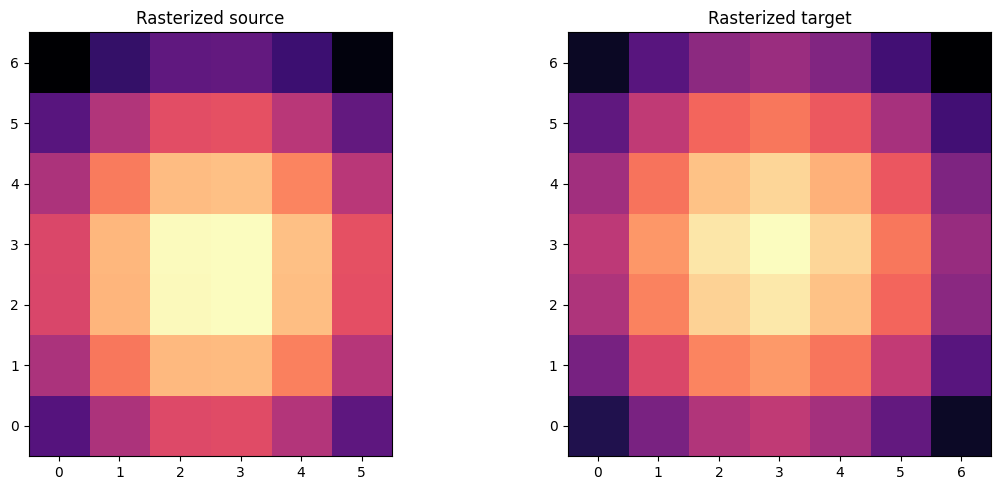

In [3]:
preprocess_config = sq.experimental.tl.stalign_tools.STalignPreprocessConfig(
    dx=40.0,
    blur=[2.0, 1.0],
)
preprocessed = sq.experimental.tl.stalign_tools.stalign_preprocess(
    source_rc,
    target_rc,
    config=preprocess_config,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(preprocessed.source_image[0], origin="lower", cmap="magma")
axes[0].set_title("Rasterized source")
axes[1].imshow(preprocessed.target_image[0], origin="lower", cmap="magma")
axes[1].set_title("Rasterized target")
plt.tight_layout()
plt.show()

In [4]:
config = sq.experimental.tl.stalign_tools.STalignConfig(
    preprocess=preprocess_config,
    registration=sq.experimental.tl.stalign_tools.STalignRegistrationConfig(
        a=300.0,
        nt=2,
        niter=10,
        diffeo_start=10,
    ),
)
result = sq.experimental.tl.stalign_tools.stalign_points(
    source_rc,
    target_rc,
    preprocessed=preprocessed,
    config=config,
    landmarks_source=landmarks_source_rc,
    landmarks_target=landmarks_target_rc,
)

aligned_rc = np.asarray(result.transform_points(source_rc, direction="forward"))
aligned_xy = aligned_rc[:, [1, 0]]
mean_abs_error = np.abs(aligned_xy - target_xy).mean()
mean_abs_error

np.float64(4.070888821645152)

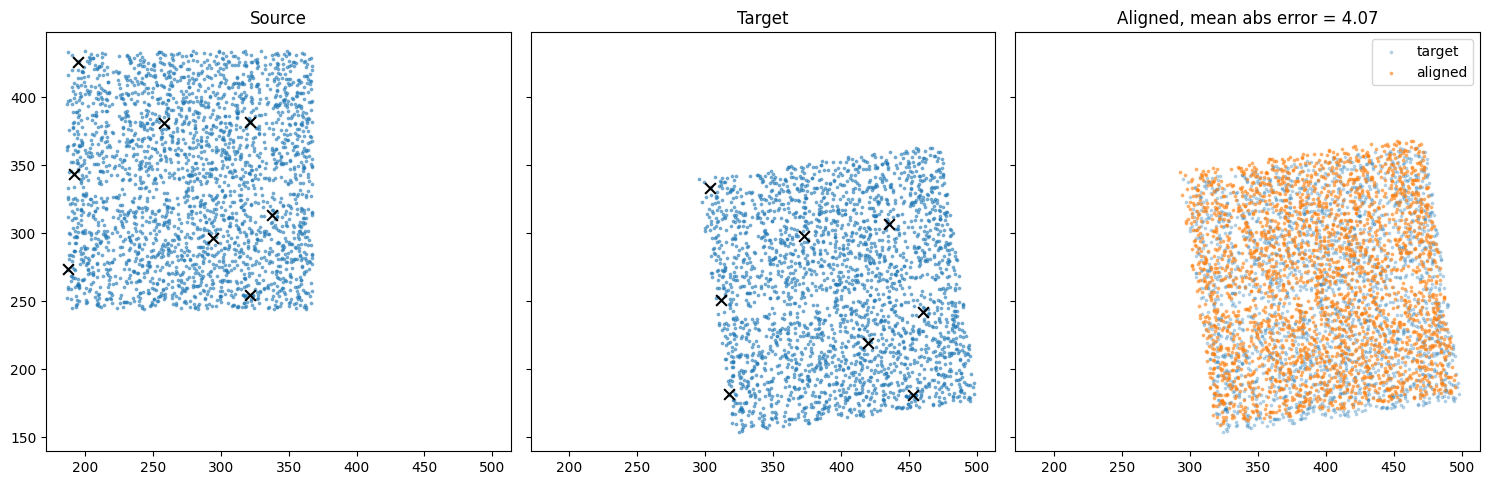

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

axes[0].scatter(source_xy[:, 0], source_xy[:, 1], s=3, alpha=0.5)
axes[0].scatter(landmarks_source_xy[:, 0], landmarks_source_xy[:, 1], s=60, c="black", marker="x")
axes[0].set_title("Source")

axes[1].scatter(target_xy[:, 0], target_xy[:, 1], s=3, alpha=0.5)
axes[1].scatter(landmarks_target_xy[:, 0], landmarks_target_xy[:, 1], s=60, c="black", marker="x")
axes[1].set_title("Target")

axes[2].scatter(target_xy[:, 0], target_xy[:, 1], s=3, alpha=0.25, label="target")
axes[2].scatter(aligned_xy[:, 0], aligned_xy[:, 1], s=3, alpha=0.5, label="aligned")
axes[2].set_title(f"Aligned, mean abs error = {mean_abs_error:.2f}")
axes[2].legend()

for ax in axes:
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()